[*********************100%***********************]  1 of 1 completed

             Adj Close
Date                  
2011-09-19  122.849998
2011-09-20  124.349998
2011-09-21  121.150002
2011-09-22  115.000000
2011-09-23  117.800003


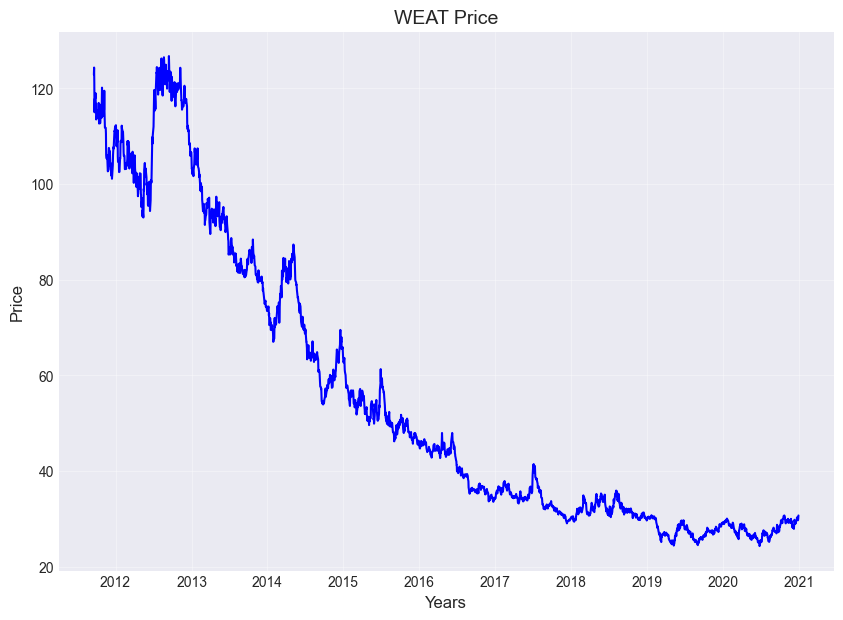

In [2]:
# Import the libraries

# Data manipulation
import numpy as np
import pandas as pd

# For statistical analysis
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf

# Import matplotlib and set the style
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

# Import warnings
import warnings
warnings.filterwarnings("ignore")

import yfinance as yf

# Download WEAT data
data = yf.download("WEAT", start="2011-01-01", end="2020-12-31",auto_adjust=False,multi_level_index=False)

# Keep only Adjusted Close
data = data[['Adj Close']]

# Drop missing values
data = data.dropna()

print(data.head())

# Drop the missing values
data = data.dropna()

# Rolling Window
rolling_window = int(len(data)*0.70)

# Plot the series
plt.figure(figsize=(10, 7))
plt.plot(data['Adj Close'], 'blue')
plt.title("WEAT Price", fontsize=14)
plt.xlabel("Years", fontsize=12)
plt.ylabel("Price", fontsize=12)
plt.show()

In [3]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(data['Adj Close'])

if(result[1] < 0.05):
    print('The series is stationary as the p-value = %.2f <= 0.05'
          % result[1])
else:
    print('The series is not stationary as the p-value = %.2f > 0.05'
          % result[1])

The series is not stationary as the p-value = 0.29 > 0.05


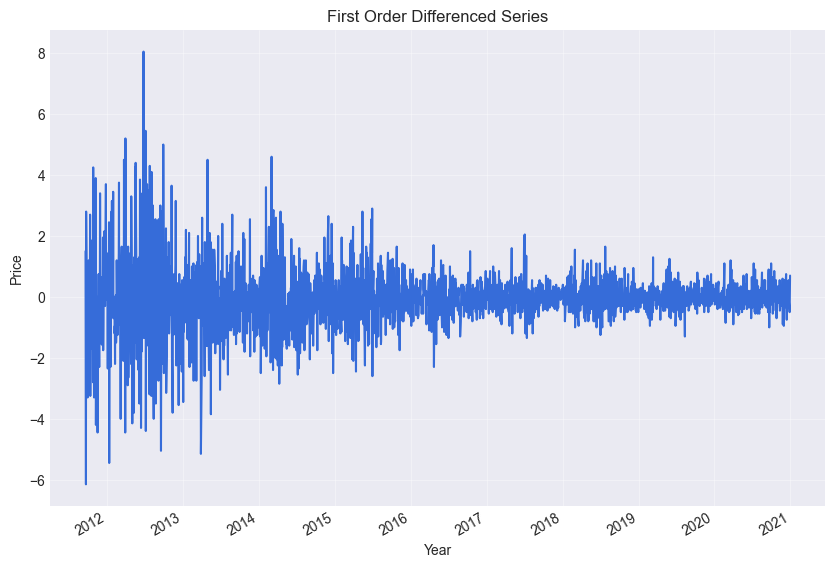

In [4]:
# Difference of the series
stationary_series = data['Adj Close'].diff().dropna()

# Plot the difference
plt.figure(figsize=(10, 7))
stationary_series.plot()
plt.title('First Order Differenced Series')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

In [5]:
result = adfuller(stationary_series)

if(result[1] < 0.05):
    print('The series is stationary as the p-value = %.2f <= 0.05'
          % result[1])
else:
    print('The series is not stationary as the p-value = %.2f > 0.05'
          % result[1])

The series is stationary as the p-value = 0.00 <= 0.05


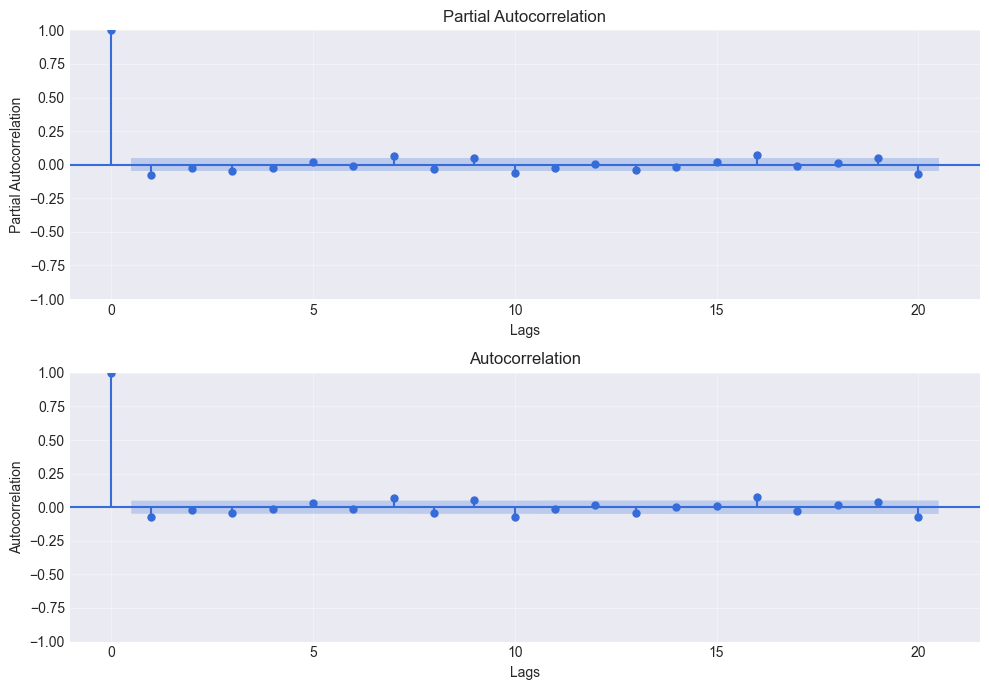

In [6]:
# Find the order of AR and MA
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))

# Plot Partial Autocorrelation Function
plot_pacf(data['Adj Close'][:rolling_window].diff().dropna(), lags=20, ax=ax1)
ax1.set_xlabel('Lags')
ax1.set_ylabel('Partial Autocorrelation')

# Plot Autocorrelation Function
plot_acf(data['Adj Close'][:rolling_window].diff().dropna(), lags=20, ax=ax2)
ax2.set_xlabel('Lags')
ax2.set_ylabel('Autocorrelation')

plt.tight_layout()
plt.show()